In [2]:
%%sql
SELECT * FROM weather_data WHERE station = "长城站"

,id,station,record_time,temperature,humidity,wind_dir,wind_speed,created_at,unique_id
0,1,长城站,2025-03-17 23:20:00,3.4,94,0,5.8,2025-03-17 23:31:29.160,长城站_20250317232000
1,43,长城站,2025-03-17 23:50:00,3.7,93,0,7.7,2025-03-18 00:01:29.206,长城站_20250317235000
2,93,长城站,2025-03-18 00:20:00,3.7,95,0,8.7,2025-03-18 00:31:29.192,长城站_20250318002000
3,155,长城站,2025-03-18 00:50:00,4.0,95,0,5.5,2025-03-18 01:01:29.228,长城站_20250318005000
4,250,长城站,2025-03-18 01:20:00,4.2,95,0,7.9,2025-03-18 01:31:29.268,长城站_20250318012000
...,...,...,...,...,...,...,...,...,...
2555,96540186,长城站,2025-06-05 08:05:00,-4.8,96,0,17.2,2025-06-05 08:31:29.292,长城站_20250605080500
2556,96632120,长城站,2025-06-05 09:05:00,-5.0,97,0,16.5,2025-06-05 09:31:29.266,长城站_20250605090500
2557,96724117,长城站,2025-06-05 10:05:00,-4.8,96,0,12.6,2025-06-05 10:31:29.253,长城站_20250605100500
2558,96816135,长城站,2025-06-05 11:05:00,-4.9,97,0,17.0,2025-06-05 11:31:29.181,长城站_20250605110500


### Step 1：数据预处理（Data Preprocessing）

LSTM网络是一种特殊类型的循环神经网络（RNN），它能够记住长期的信息并解决传统RNN的长期依赖问题。

- 数据预处理：清洗数据，处理缺失值，进行标准化或归一化。
- 特征工程：选择与气温预测相关的时间序列特征。
- 模型构建：设计LSTM网络结构，包括确定网络层数、神经元数量等。
- 训练与验证：使用历史气温数据训练模型，并通过交叉验证评估模型性能。
- 预测与评估：使用训练好的模型进行未来气温预测，并与实际数据进行比较以评估准确性。


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 保证数据按时间排序
df_great_wall['record_time'] = pd.to_datetime(df_great_wall['record_time'])
df_great_wall = df_great_wall.sort_values('record_time')

# 选择用于预测的特征
features = ['temperature', 'humidity', 'wind_speed']
data = df_great_wall[features].copy()

# 检查并处理缺失值
data = data.dropna()

# —— 拆分 ——
full_data = df_great_wall[features].dropna().values
train_raw = full_data[:-200]
val_raw   = full_data[-200:]

# —— 仅在训练集上 fit scaler ——
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_raw)
val_data   = scaler.transform(val_raw)

###  Step 2：构建时序数据（特征工程）

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

SEQ_LENGTH = 10  # 时间窗口长度 10步 = 5小时
HORIZON = 4 # 预测步数，2小时
input_size = len(features) # 特征维度：temperature, humidity, wind_speed

def create_sequences(data, seq_length, horizon):
    xs, ys = [], []
    for i in range(len(data) - seq_length - horizon + 1):
        x = data[i : i + seq_length]
        y = data[i + seq_length : i + seq_length + horizon]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X_train, y_train = create_sequences(train_data, SEQ_LENGTH, HORIZON)
X_val,   y_val   = create_sequences(val_data,   SEQ_LENGTH, HORIZON)


# 转换为Tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)


# 创建Dataset和DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=32)

### Step 3：构建LSTM模型（Model Building）

In [5]:
import torch.nn as nn

class LSTMForecast(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, horizon):
        super().__init__()
        self.horizon = horizon
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # 输出维度 = hidden_size → (input_size * horizon)
        self.fc      = nn.Linear(hidden_size, input_size * horizon)

    def forward(self, x):
        out, _ = self.lstm(x)                   # (batch, seq_length, hidden_size)
        h_n     = out[:, -1, :]                 # (batch, hidden_size)
        y       = self.fc(h_n)                  # (batch, input_size*horizon)
        # reshape 到 (batch, horizon, input_size)
        return y.view(-1, self.horizon, input_size)

model = LSTMForecast(
    input_size = input_size,
    hidden_size=64,
    num_layers =2,
    horizon    =HORIZON
)

### Step 4：训练模型（Training）

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()

    print(f"Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# 保存模型参数
torch.save(model.state_dict(), "lstm_forecast.pt")

Epoch 1, Train Loss: 5.7867, Val Loss: 0.1442
Epoch 2, Train Loss: 1.1977, Val Loss: 0.1306
Epoch 3, Train Loss: 0.9235, Val Loss: 0.0623
Epoch 4, Train Loss: 0.6988, Val Loss: 0.0389
Epoch 5, Train Loss: 0.5743, Val Loss: 0.0411
Epoch 6, Train Loss: 0.5393, Val Loss: 0.0243
Epoch 7, Train Loss: 0.5122, Val Loss: 0.0354
Epoch 8, Train Loss: 0.4737, Val Loss: 0.0241
Epoch 9, Train Loss: 0.4448, Val Loss: 0.0198
Epoch 10, Train Loss: 0.4382, Val Loss: 0.0246
Epoch 11, Train Loss: 0.4292, Val Loss: 0.0185
Epoch 12, Train Loss: 0.4086, Val Loss: 0.0236
Epoch 13, Train Loss: 0.3905, Val Loss: 0.0212
Epoch 14, Train Loss: 0.3765, Val Loss: 0.0180
Epoch 15, Train Loss: 0.3649, Val Loss: 0.0176
Epoch 16, Train Loss: 0.3533, Val Loss: 0.0156
Epoch 17, Train Loss: 0.3504, Val Loss: 0.0226
Epoch 18, Train Loss: 0.3368, Val Loss: 0.0176
Epoch 19, Train Loss: 0.3495, Val Loss: 0.0175
Epoch 20, Train Loss: 0.3265, Val Loss: 0.0186
Epoch 21, Train Loss: 0.3237, Val Loss: 0.0191
Epoch 22, Train Loss: 

### Step 5：预测与评估（Prediction and Evaluation）

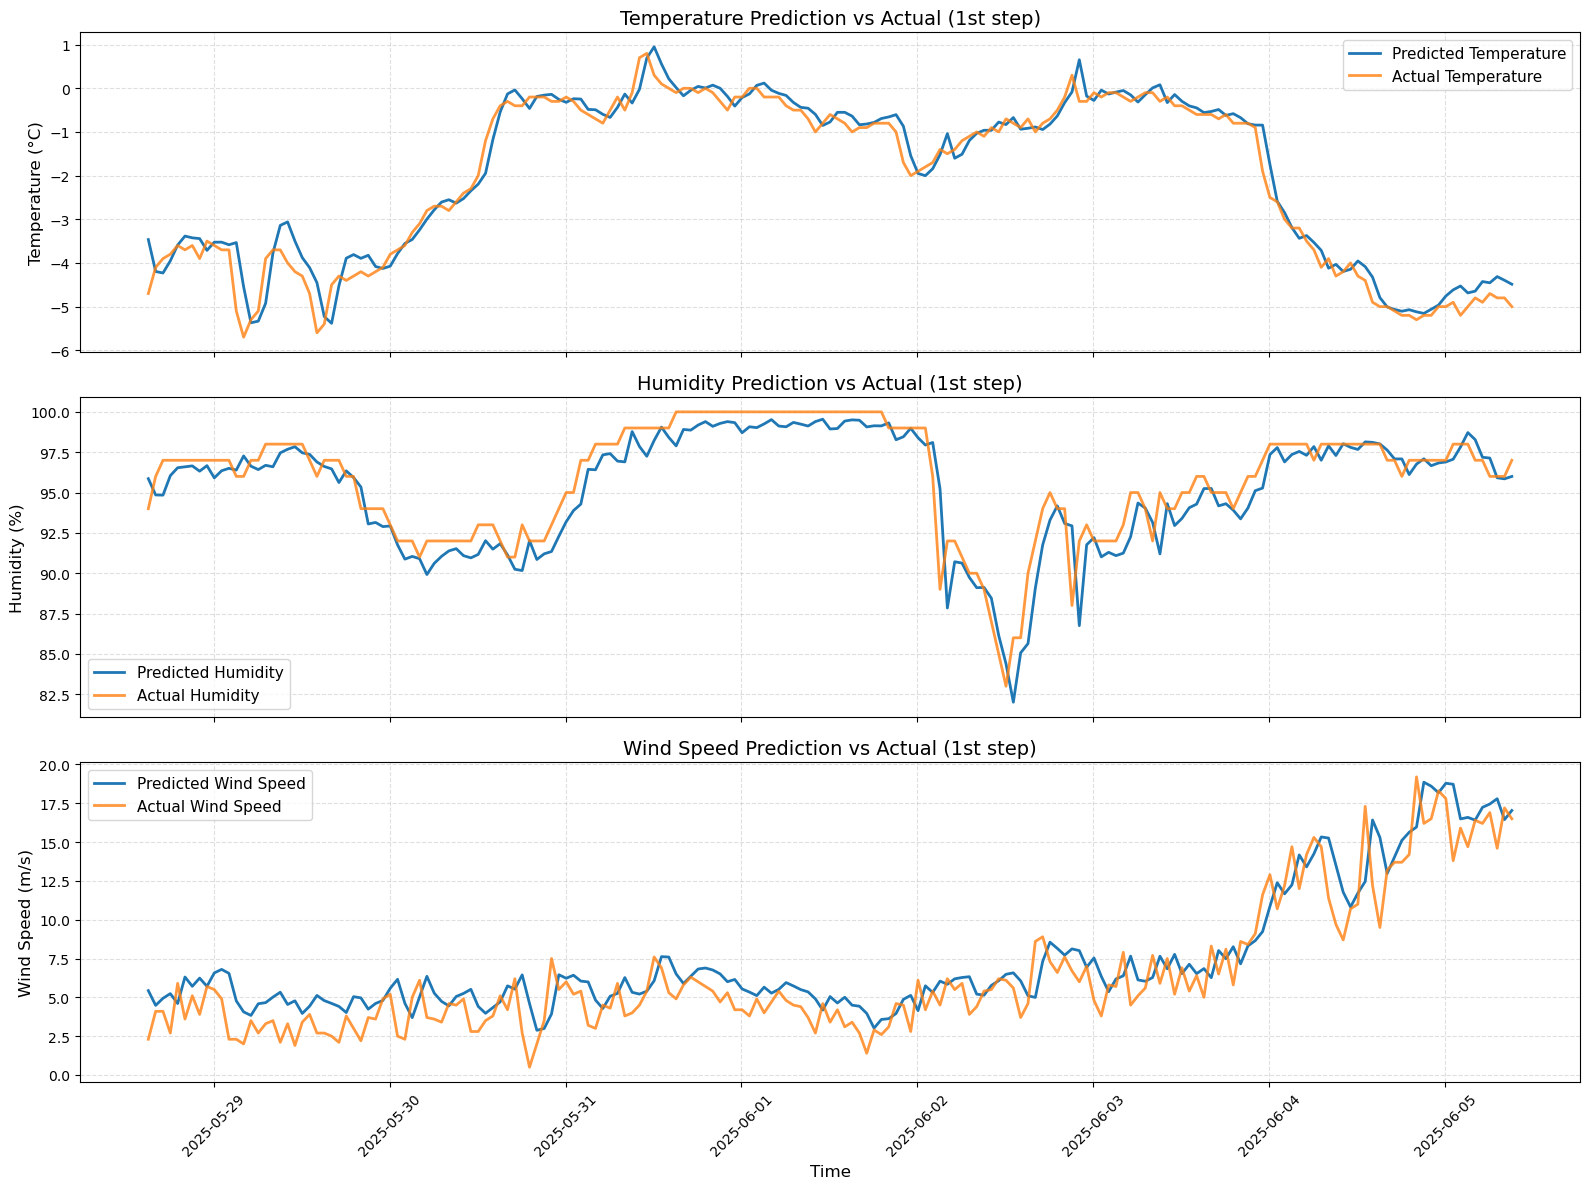

In [7]:
import matplotlib.pyplot as plt

# 1. Model prediction & inverse transform
model.eval()
with torch.no_grad():
    preds = model(X_val).numpy()

# 只保留每个窗口预测的第1步
preds_1step = preds[:, 0, :]  # shape: [batch, input_size]
truth_1step = y_val.numpy()[:, 0, :]  # shape: [batch, input_size]

# 逆标准化
# inverse transform
preds_1step_rescaled = scaler.inverse_transform(preds_1step)
truth_1step_rescaled = scaler.inverse_transform(truth_1step)

# 时间轴：对应预测起点 + 1 step（30分钟）
times = df_great_wall['record_time'].iloc[-len(val_raw) + SEQ_LENGTH : -HORIZON + 1]  # 对应每个窗口的起点

# 绘图
fig, axs = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
labels = [('Temperature', '°C'), ('Humidity', '%'), ('Wind Speed', 'm/s')]

for i, (name, unit) in enumerate(labels):
    axs[i].plot(times, preds_1step_rescaled[:, i], label=f'Predicted {name}', linewidth=2)
    axs[i].plot(times, truth_1step_rescaled[:, i], label=f'Actual {name}', linewidth=2, alpha=0.8)
    axs[i].set_ylabel(f'{name} ({unit})', fontsize=12)
    axs[i].legend(fontsize=11)
    axs[i].grid(True, linestyle='--', alpha=0.4)
    axs[i].set_title(f'{name} Prediction vs Actual (1st step)', fontsize=14)

axs[-1].set_xlabel('Time', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

feature_names = ['Temperature', 'Humidity', 'Wind Speed']

print("Evaluation Metrics for 1-step Prediction:\n")
for i, name in enumerate(feature_names):
    y_true = truth_1step_rescaled[:, i]
    y_pred = preds_1step_rescaled[:, i]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)  # ✅ 兼容旧版本
    r2 = r2_score(y_true, y_pred)

    print(f"{name}:")
    print(f"  MAE:  {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²:   {r2:.3f}\n")

Evaluation Metrics for 1-step Prediction:

Temperature:
  MAE:  0.251
  RMSE: 0.359
  R²:   0.964

Humidity:
  MAE:  0.993
  RMSE: 1.373
  R²:   0.837

Wind Speed:
  MAE:  1.446
  RMSE: 1.830
  R²:   0.804



DTW 计算滞后程度

In [9]:
from dtaidistance import dtw

print("\nDTW Distance Analysis (1-step prediction):")

for i, name in enumerate(['Temperature', 'Humidity', 'Wind Speed']):
    y_true = truth_1step_rescaled[:, i]
    y_pred = preds_1step_rescaled[:, i]

    # 计算 DTW 距离（可反映形态相似性和滞后性）
    dtw_distance = dtw.distance(y_true, y_pred)

    print(f"{name}: DTW Distance = {dtw_distance:.4f}")



DTW Distance Analysis (1-step prediction):
Temperature: DTW Distance = 2.4686
Humidity: DTW Distance = 8.2360
Wind Speed: DTW Distance = 13.3134
